# 👥 HR Employee Attrition Analytics
**Level:** Advanced · **Tools:** Python (Pandas, Seaborn, Scikit-learn), statistical testing, Tableau-ready data model

**Business problem:** HR wants to know **why employees leave**, **who is most at risk**, and **what attrition costs**, so it can target retention budgets.

**Dataset:** [IBM HR Analytics Employee Attrition](https://github.com/IBM/employee-attrition-aif360): 1,470 employees, 35 attributes (demographics, role, pay, satisfaction, overtime, tenure).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, classification_report
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
df = pd.read_csv("data/ibm_hr_attrition.csv")
df = df.drop(columns=["EmployeeCount","Over18","StandardHours"])   # constant columns
df["Left"] = (df.Attrition == "Yes").astype(int)
print(df.shape, "| missing:", df.isna().sum().sum(), f"| attrition rate: {df.Left.mean():.1%}")

(1470, 33) | missing: 0 | attrition rate: 16.1%


## 1. Attrition across the organisation

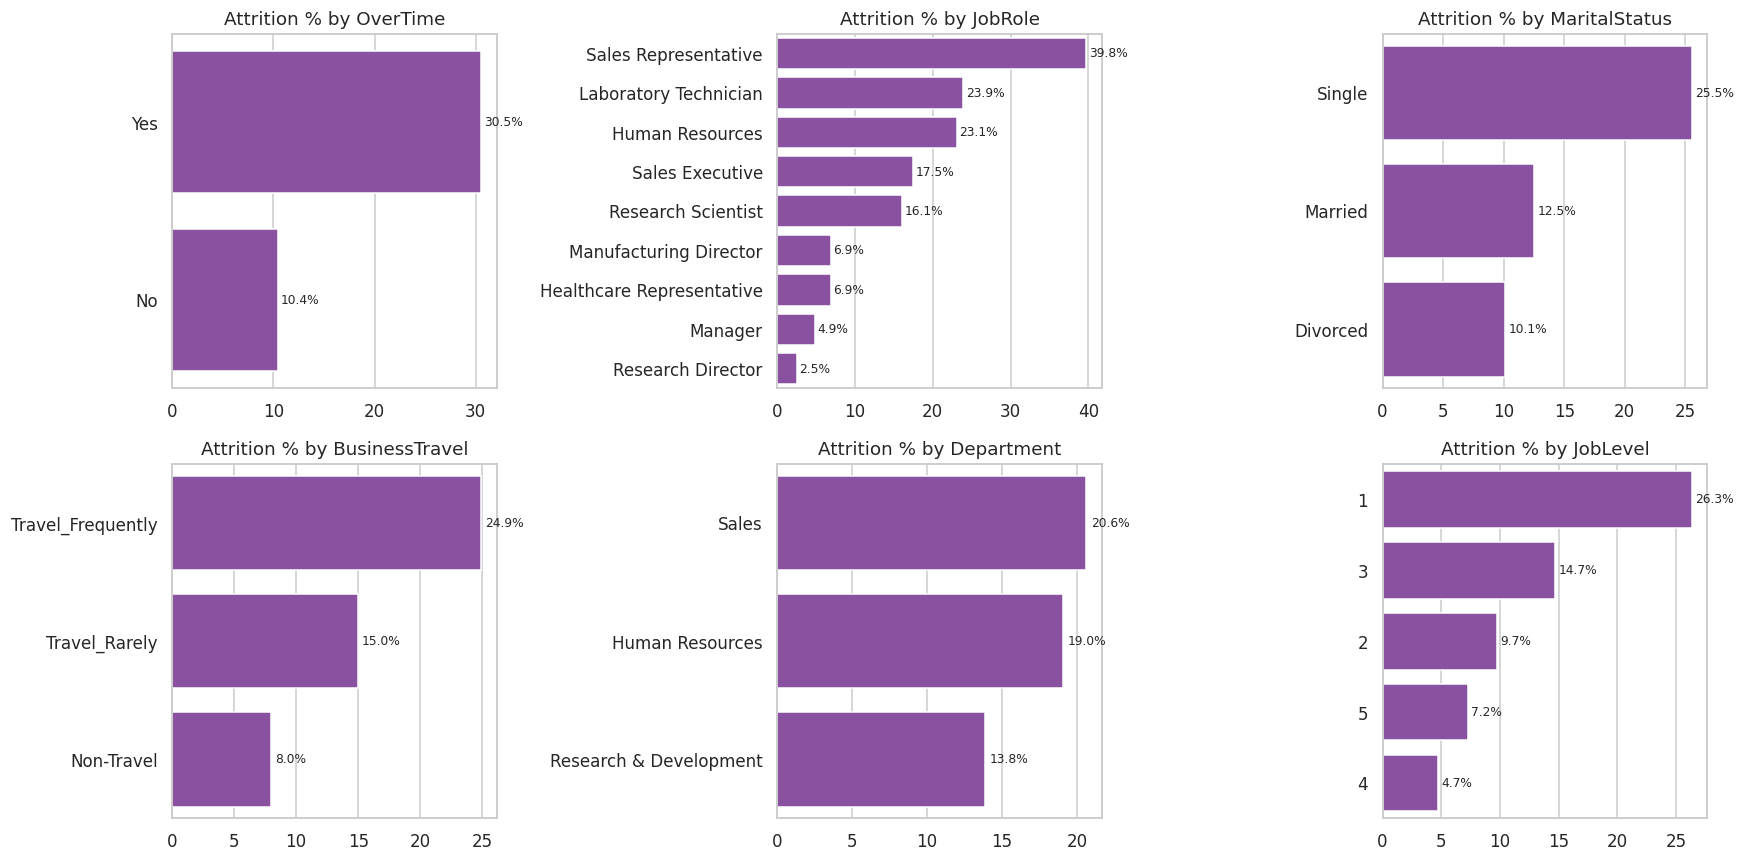

In [2]:
fig, axes = plt.subplots(2,3, figsize=(16,8))
for ax, col in zip(axes.flat, ["OverTime","JobRole","MaritalStatus","BusinessTravel","Department","JobLevel"]):
    r = df.groupby(col).Left.mean().sort_values(ascending=False)*100
    sns.barplot(x=r.values, y=r.index.astype(str), ax=ax, color="#8E44AD"); ax.set_title(f"Attrition % by {col}"); ax.set_xlabel(""); ax.set_ylabel("")
    for i,v in enumerate(r.values): ax.text(v+0.3, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout(); plt.savefig("images/attrition_by_category.png", bbox_inches="tight"); plt.show()

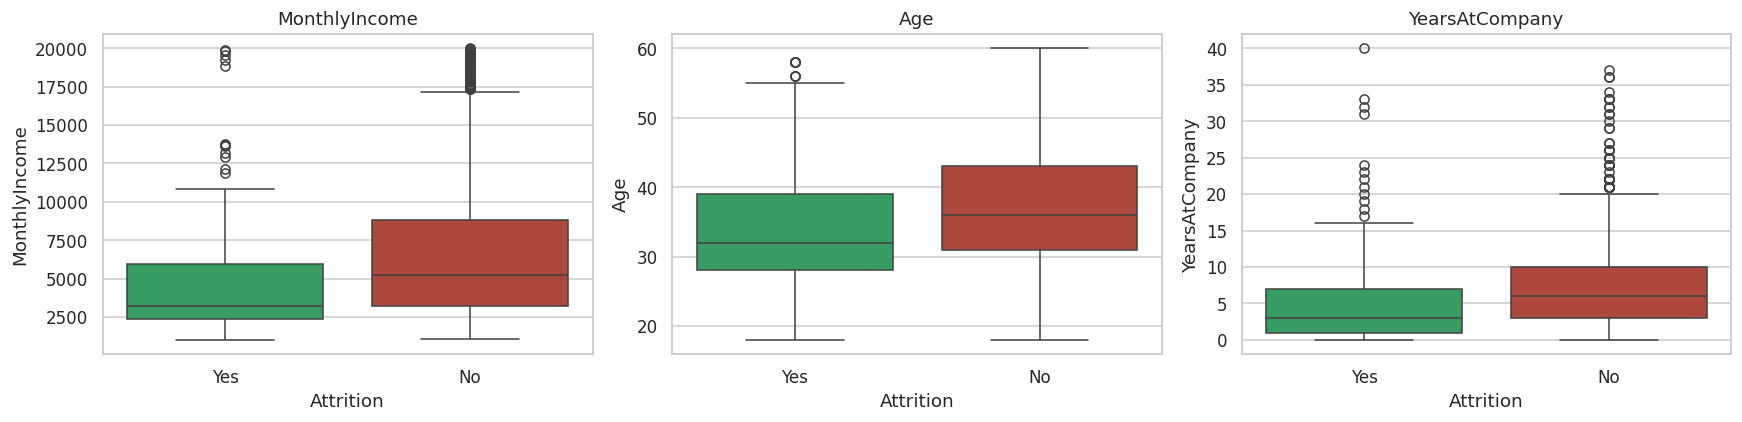

,MonthlyIncome,Age,YearsAtCompany,TotalWorkingYears,DistanceFromHome
Attrition,,,,,
No,5204.0,36.0,6.0,10.0,7.0
Yes,3202.0,32.0,3.0,7.0,9.0


In [3]:
fig, axes = plt.subplots(1,3, figsize=(16,4))
for ax, col in zip(axes, ["MonthlyIncome","Age","YearsAtCompany"]):
    sns.boxplot(data=df, x="Attrition", y=col, ax=ax, palette=["#27AE60","#C0392B"], hue="Attrition", legend=False); ax.set_title(col)
plt.tight_layout(); plt.savefig("images/numeric_drivers.png", bbox_inches="tight"); plt.show()
df.groupby("Attrition")[["MonthlyIncome","Age","YearsAtCompany","TotalWorkingYears","DistanceFromHome"]].median()

## 2. Which differences are statistically significant?
Chi-square tests for categorical features and Mann-Whitney U tests for numeric ones, at α = 0.05.

In [4]:
rows=[]
for c in ["OverTime","JobRole","MaritalStatus","BusinessTravel","Department","Gender","EducationField","JobSatisfaction","EnvironmentSatisfaction","WorkLifeBalance","JobInvolvement","StockOptionLevel"]:
    p = chi2_contingency(pd.crosstab(df[c], df.Left))[1]; rows.append([c,"Chi-square",p])
for c in ["MonthlyIncome","Age","YearsAtCompany","TotalWorkingYears","DistanceFromHome","PercentSalaryHike","YearsSinceLastPromotion"]:
    p = mannwhitneyu(df.loc[df.Left==1,c], df.loc[df.Left==0,c])[1]; rows.append([c,"Mann-Whitney U",p])
tests = pd.DataFrame(rows, columns=["Feature","Test","p_value"]).sort_values("p_value")
tests["Significant"] = np.where(tests.p_value < 0.05, "✅ yes", "no"); tests["p_value"] = tests.p_value.map("{:.2e}".format); tests

,Feature,Test,p_value,Significant
0,OverTime,Chi-square,8.16e-21,✅ yes
1,JobRole,Chi-square,2.75e-15,✅ yes
15,TotalWorkingYears,Mann-Whitney U,2.40e-14,✅ yes
12,MonthlyIncome,Mann-Whitney U,2.95e-14,✅ yes
14,YearsAtCompany,Mann-Whitney U,2.92e-13,✅ yes
11,StockOptionLevel,Chi-square,4.38e-13,✅ yes
13,Age,Mann-Whitney U,5.30e-11,✅ yes
2,MaritalStatus,Chi-square,9.46e-11,✅ yes
10,JobInvolvement,Chi-square,2.86e-06,✅ yes
3,BusinessTravel,Chi-square,5.61e-06,✅ yes


## 3. Predictive model: who is at risk?

In [5]:
X = df.drop(columns=["Attrition","Left","EmployeeNumber"]); y = df.Left
cat = X.select_dtypes(exclude="number").columns.tolist(); num = [c for c in X.columns if c not in cat]
pre = ColumnTransformer([("num", StandardScaler(), num), ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat)])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=7)
lr = Pipeline([("pre",pre),("m",LogisticRegression(max_iter=3000, class_weight="balanced", C=0.5))]).fit(X_tr,y_tr)
rf = Pipeline([("pre",pre),("m",RandomForestClassifier(n_estimators=500, min_samples_leaf=3, class_weight="balanced_subsample", random_state=7))]).fit(X_tr,y_tr)
for name, mdl in [("Logistic Regression", lr), ("Random Forest", rf)]:
    print(f"{name}: ROC-AUC = {roc_auc_score(y_te, mdl.predict_proba(X_te)[:,1]):.3f}")
print(classification_report(y_te, lr.predict(X_te), target_names=["Stayed","Left"]))

Logistic Regression: ROC-AUC = 0.857
Random Forest: ROC-AUC = 0.837
              precision    recall  f1-score   support

      Stayed       0.95      0.75      0.84       309
        Left       0.38      0.78      0.51        59

    accuracy                           0.76       368
   macro avg       0.66      0.77      0.67       368
weighted avg       0.86      0.76      0.79       368



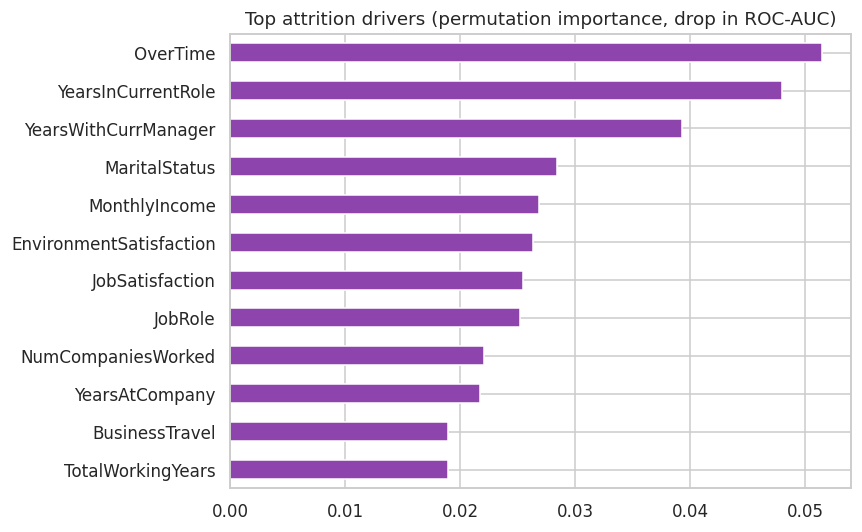

In [6]:
pi = permutation_importance(lr, X_te, y_te, scoring="roc_auc", n_repeats=20, random_state=7)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8,5)); imp.sort_values().plot.barh(ax=ax, color="#8E44AD")
ax.set_title("Top attrition drivers (permutation importance, drop in ROC-AUC)"); plt.tight_layout()
plt.savefig("images/feature_importance.png", bbox_inches="tight"); plt.show()

## 4. Cost of attrition & a high-risk profile

In [7]:
# Replacement cost assumption: ~50% of annual salary (industry rule of thumb: 30–200%)
leavers = df[df.Left==1]; cost = (leavers.MonthlyIncome*12*0.5).sum()
print(f"Employees who left: {len(leavers)} | Estimated replacement cost: ${cost:,.0f} (≈ ${cost/len(leavers):,.0f} per leaver)")
seg = df.assign(Young=df.Age<30, LowPay=df.MonthlyIncome<df.MonthlyIncome.quantile(0.25))
combo = seg.groupby(["OverTime","LowPay"]).Left.agg(["mean","count"]).rename(columns={"mean":"attrition_rate"})
combo["attrition_rate"] = (combo.attrition_rate*100).round(1); combo

Employees who left: 237 | Estimated replacement cost: $6,807,246 (≈ $28,723 per leaver)


attrition_rate  count
OverTime LowPay                       
No       False              8.1    793
         True              17.6    261
Yes      False             21.0    310
         True              58.5    106

In [8]:
# Tableau-ready extract: one row per employee with banded fields + model risk score
out = df.copy()
out["RiskScore"] = lr.predict_proba(X)[:,1].round(3)
out["RiskTier"] = pd.cut(out.RiskScore, [0,0.3,0.6,1], labels=["Low","Medium","High"], include_lowest=True)
out["AgeBand"] = pd.cut(out.Age, [17,25,35,45,60], labels=["18-25","26-35","36-45","46-60"])
out["IncomeBand"] = pd.qcut(out.MonthlyIncome, 4, labels=["Q1 (lowest)","Q2","Q3","Q4 (highest)"])
out["TenureBand"] = pd.cut(out.YearsAtCompany, [-1,2,5,10,40], labels=["0-2 yrs","3-5 yrs","6-10 yrs","10+ yrs"])
out["AnnualReplacementCost"] = np.where(out.Left==1, out.MonthlyIncome*12*0.5, 0)
out.to_csv("tableau/hr_attrition_tableau.csv", index=False)
print(out.RiskTier.value_counts()); print("Saved tableau/hr_attrition_tableau.csv", out.shape)

RiskTier
Low       703
Medium    418
High      349
Name: count, dtype: int64
Saved tableau/hr_attrition_tableau.csv (1470, 39)


## 5. Recommendations
1. **Overtime is the #1 lever.** Staff working overtime leave far more often. Cap sustained overtime, add hiring in overloaded teams, and pay or recognise the overtime.
2. **Protect early-career, lower-paid staff** (Sales Representatives, Lab Technicians, Job Level 1). Review pay bands and set clear promotion paths.
3. **Stock options work.** Employees with no stock options leave more; extend equity or retention bonuses to high-risk tiers.
4. **Frequent business travel and single employees** show higher attrition. Offer travel flexibility and community or engagement programmes.
5. Use the **risk score** in the Tableau dashboard to run monthly stay-interviews with the High-risk tier.